In [14]:
import pandas as pd

## 1. 데이터 전처리

In [15]:
train_df = pd.read_csv("data_train.csv")
test_df = pd.read_csv("data_test.csv")

train_df.head()

,temperature(C),wind speed(m/s),wind direction,humidity(%),vapor pressure(hPa),dew point(C),atmospheric pressure(hPa),Sea level pressure(hPa),insolation time(hr),insolation(MJ/m2),cloud,weather label
0,23.1,1.3,90.0,84.0,23.7,20.2,999.3,1005.5,NaN,NaN,10,1
1,25.5,1.1,70.0,63.0,20.5,17.9,1017.3,1018.8,0.9,NaN,4,0
2,4.2,2.1,250.0,88.0,7.2,2.3,1002.9,1030.4,NaN,NaN,8,1
3,5.4,1.0,90.0,21.0,1.9,-15.2,1027.4,1030.8,1.0,NaN,6,3
4,23.6,2.7,250.0,26.0,7.5,2.9,1004.1,1014.4,1.0,3.39,0,0


In [16]:
train_df.info()
train_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2058 entries, 0 to 2057
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   temperature(C)             2056 non-null   float64
 1   wind speed(m/s)            2057 non-null   float64
 2   wind direction             2057 non-null   float64
 3   humidity(%)                2056 non-null   float64
 4   vapor pressure(hPa)        2055 non-null   float64
 5   dew point(C)               2055 non-null   float64
 6   atmospheric pressure(hPa)  2057 non-null   float64
 7   Sea level pressure(hPa)    2056 non-null   float64
 8   insolation time(hr)        1062 non-null   float64
 9   insolation(MJ/m2)          848 non-null    float64
 10  cloud                      2058 non-null   int64  
 11  weather label              2058 non-null   int64  
dtypes: float64(10), int64(2)
memory usage: 193.1 KB


temperature(C)                  2
wind speed(m/s)                 1
wind direction                  1
humidity(%)                     2
vapor pressure(hPa)             3
dew point(C)                    3
atmospheric pressure(hPa)       1
Sea level pressure(hPa)         2
insolation time(hr)           996
insolation(MJ/m2)            1210
cloud                           0
weather label                   0
dtype: int64

### 1-1)결측치 해결

#### 1-1-1)
- insolation time(hr)  → 996개 결측 (거의 50% 없음)
- insolation(MJ/m2)    → 1210개 결측 (거의 60% 없음)
=> 너무 많이 비어 있어 신뢰도가 떨어짐
=> 두 칼럼 버리기

In [17]:
drop_cols = ["insolation time(hr)", "insolation(MJ/m2)"]

train_df = train_df.drop(columns = drop_cols)
test_df = test_df.drop(columns = drop_cols)

In [18]:
# 입력과 출력 분리
X = train_df.drop(columns=["weather label"])
y = train_df["weather label"]

#### 1-1-2)
나머지 칼럼의 결측치는 1~3개 수준으로 살려서 쓰기
median으로 채우기
이유) 평균보다 이상치 영향 덜 받으면서 날씨 데이터에 적합함

In [19]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy = "median")

X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

### 1-2) 방향 데이터 개선
:wind direction 칼럼 처리
지금 상태: 90, 270, 0,...
=> 0도와 360도는 같은 방향인데 모델은 멀다고 생각함

해결) sin(좌우), cos(상하)을 사용해서 2차원 평면 위 고유한 점으로 나타냄


In [20]:
import numpy as np

# 라디안 변환 및 sin/cos 계산
X["wind_dir_sin"] = np.sin(np.radians(X["wind direction"]))
X["wind_dir_cos"] = np.cos(np.radians(X["wind direction"]))

X = X.drop(columns=["wind direction"])

In [21]:
print(X.head())


   temperature(C)  wind speed(m/s)  humidity(%)  vapor pressure(hPa)  \
0            23.1              1.3         84.0                 23.7   
1            25.5              1.1         63.0                 20.5   
2             4.2              2.1         88.0                  7.2   
3             5.4              1.0         21.0                  1.9   
4            23.6              2.7         26.0                  7.5   

   dew point(C)  atmospheric pressure(hPa)  Sea level pressure(hPa)  cloud  \
0          20.2                      999.3                   1005.5   10.0   
1          17.9                     1017.3                   1018.8    4.0   
2           2.3                     1002.9                   1030.4    8.0   
3         -15.2                     1027.4                   1030.8    6.0   
4           2.9                     1004.1                   1014.4    0.0   

   wind_dir_sin  wind_dir_cos  
0      1.000000  6.123234e-17  
1      0.939693  3.420201e-01  
2 

## 2. 데이터 나누기
공부용(train)과 모의고사용(val)으로 나누기
과적합 방지를 위해

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train", X_train.shape)
print("Validation:", X_val.shape)

Train (1646, 10)
Validation: (412, 10)


## 3. 학습하기 Rondom Forest
Decision Tree의 Forest
Random으로 feature를 선정해 node로 지정하고, 분기마다 Decision Tree와 같은 방식으로 지니 불순도를 파악하여 분기해나가는 Weaker learner를 여러개 만들어 비교하고 그 안에서 최적의 예측을 하는 모델이다
1. 부트스트랩 샘플링
RandomForest를 마들기위한 각각의 Weaker learner를 만들기 위해 사용하는 샘플링 방법으로 임의로 Feature를 뽑고, 그 Feature안에서도 임의로 Sample을 복원 추출 하여 뽑는 방법
2. 분기와 임의의 특성 선택
분기 시 다음 특성을 고를 때에도 Random한 방식을 취한다. Bagging이라고 하는 이특징은 BootStrap sampling을 한 Data set에서 Feature를 임의로 선정해 여러 Tree 분류기를 만드는 것으로 Ensemble 기법이라고 할 수 있다.
과적합을 예방해주는 강점이 있다
3. OOB 검증(Out of Bag data validation)
DataSet 내에서 여러개의 New dataset을 복원 추출함으로써 그 자체적인 검증도 어느정도 진행을 한다. 뽑히지 않는 샘플을 검증 셋으로 두어 자체적인 검증을 진행한다.

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

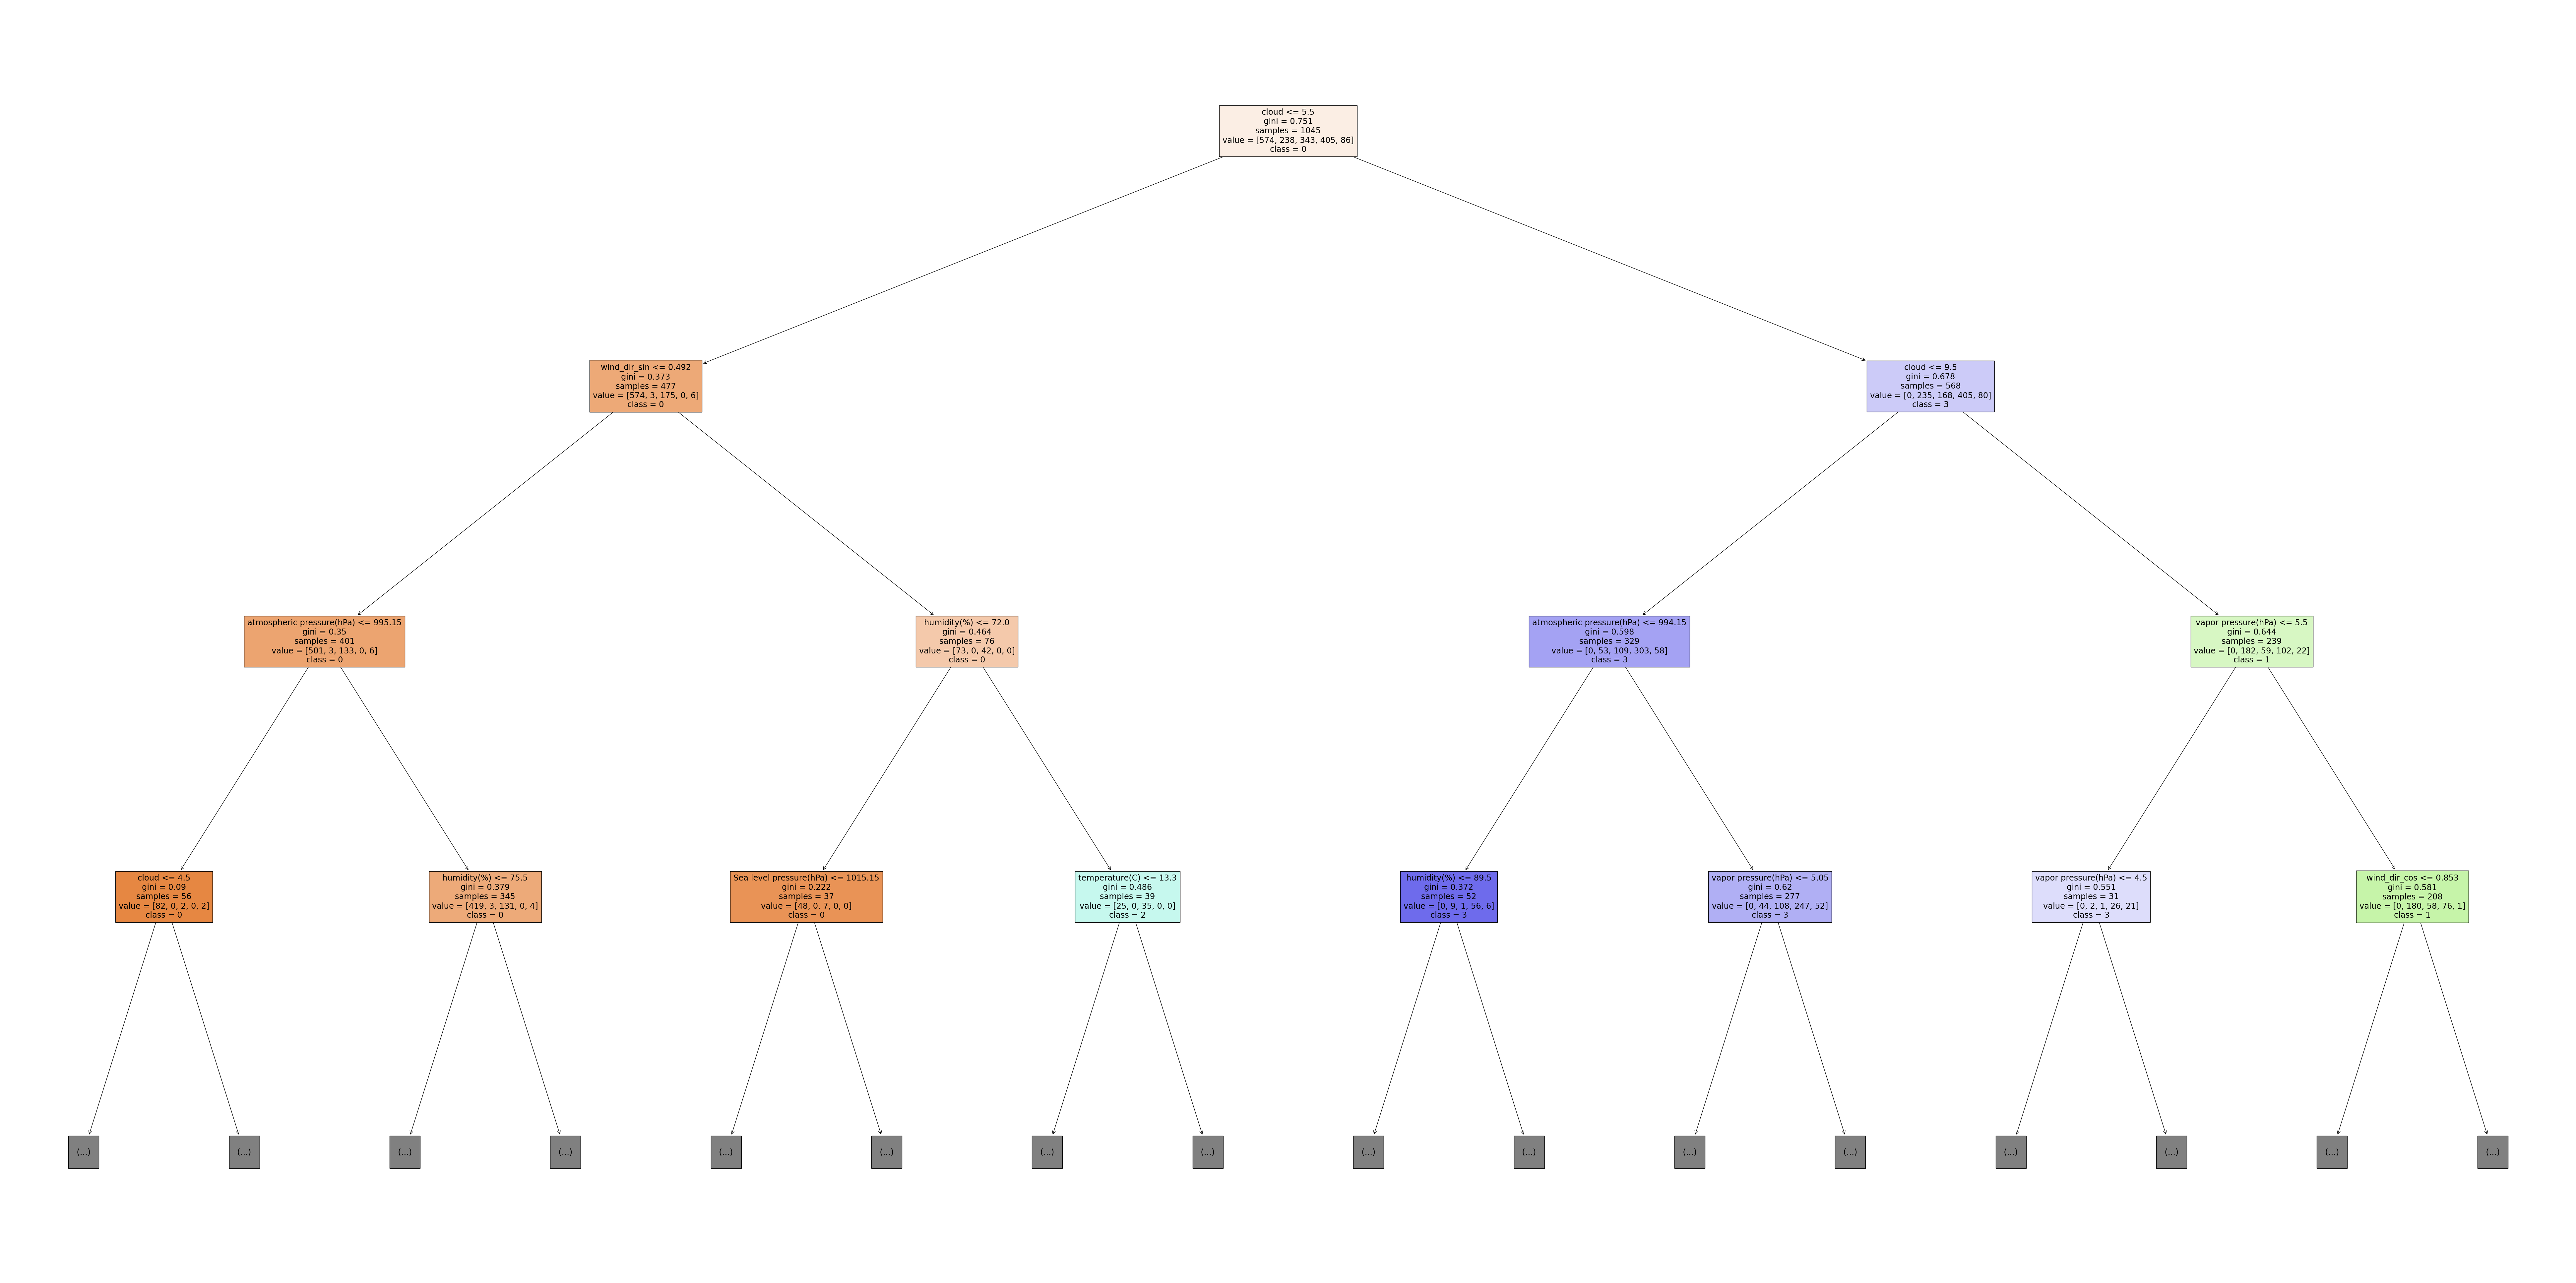

In [28]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(100, 50))
plot_tree(model.estimators_[0], 
          feature_names=X.columns, 
          class_names=[str(c) for c in model.classes_], 
          filled=True, 
          max_depth=3) 
plt.show()

In [31]:
pred_val = model.predict(X_val)

#성능 판단
print("Validation Accuracy:", accuracy_score(y_val, pred_val))

Validation Accuracy: 0.7087378640776699


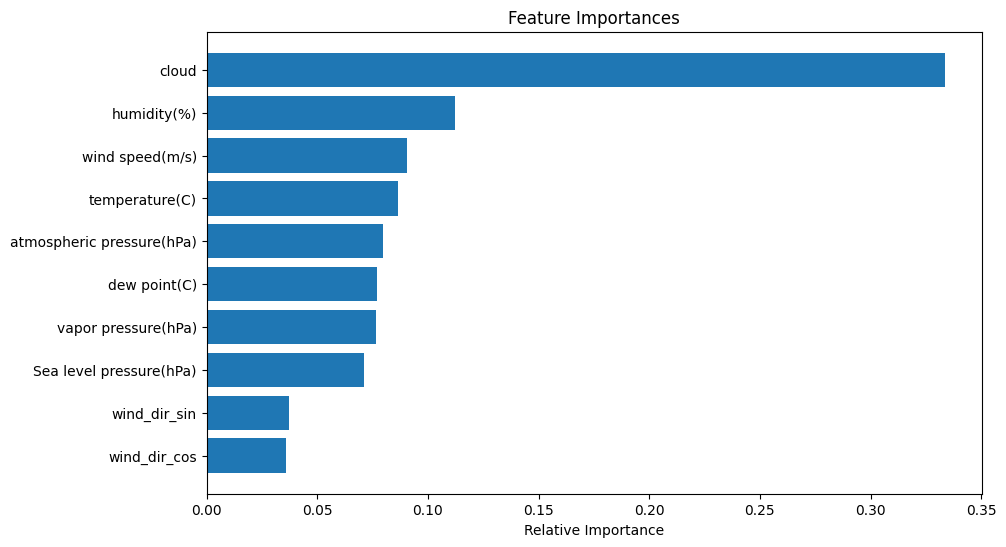

In [32]:
# Feature Importance

import matplotlib.pyplot as plt

importances = model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

## 4. Feature Engineering(파생변수 만들기)
성능이 0.7로 더 성능을 높이고자 변수 조합을 통해 파생 변수를 만들고자 한다.
- 이슬점 편차: 기온과 이슬점이 가까울수록 비가 올 확률이 높다.
- 체감 온도: 습도가 높으면 체감 온도가 올라가고 이는 대기 불안정으로 이어진다
- 기압차: 해면 기압과 현지 기압의 차이를 통해 고도나 대기 상태의 미세한 변화를 포착한다.


In [33]:
import pandas as pd
import numpy as np

# 1. 이슬점 편차
X['temp_dew_diff'] = X['temperature(C)'] - X['dew point(C)']

# 2. 체감 온도
X['apparent_temp'] = X['temperature(C)'] * 0.7 + X['humidity(%)'] * 0.01

# 3. 대기 압력 균형
X['pressure_diff'] = X['Sea level pressure(hPa)'] - X['atmospheric pressure(hPa)']

# 4. 불쾌지수 (THI)
X['THI'] = 1.8 * X['temperature(C)'] - 0.55 * (1 - X['humidity(%)']/100) * (1.8 * X['temperature(C)'] - 26) + 32


## 5. 불필요한 변수 제거 및 정규화
중요도가 너무 낮은 변수는 합치거나 제거
- 기압 통합: 세가지 기압 데이터중 하나만 남기거나 평균을 사용(나중에 고려)
- 풍향/풍속 결합: 풍향(sin, cos)과 풍속을 곱해 '바람의 벡터' 성분으로 만들기

In [34]:
# 풍향 성분에 풍속의 세기를 반영
X['wind_u'] = X['wind speed(m/s)'] * X['wind_dir_cos']
X['wind_v'] = X['wind speed(m/s)'] * X['wind_dir_sin']

# 원래의 낮은 중요도 변수들은 제거 검토
# df.drop(['wind_dir_sin', 'wind_dir_cos'], axis=1, inplace=True)

## 6. 다시 학습

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [36]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,   # 증가
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [37]:
from sklearn.metrics import accuracy_score

pred_val = model.predict(X_val)

print("Validation Accuracy:", accuracy_score(y_val, pred_val))

Validation Accuracy: 0.7451456310679612
